# Water Segmentation using U-Net

In [128]:
# =====================================
# Import Required Libraries
# =====================================

import os
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [129]:
# =====================================
# Dataset Paths
# =====================================

DATA_DIR = "data"

IMAGE_DIR = os.path.join(DATA_DIR, "images")
LABEL_DIR = os.path.join(DATA_DIR, "labels")

In [130]:
# =====================================
# Read Image and Label Names
# =====================================

image_files = sorted(os.listdir(IMAGE_DIR))
label_files = sorted(os.listdir(LABEL_DIR))

print(f"Number of Images : {len(image_files)}")
print(f"Number of Labels : {len(label_files)}")

Number of Images : 306
Number of Labels : 456


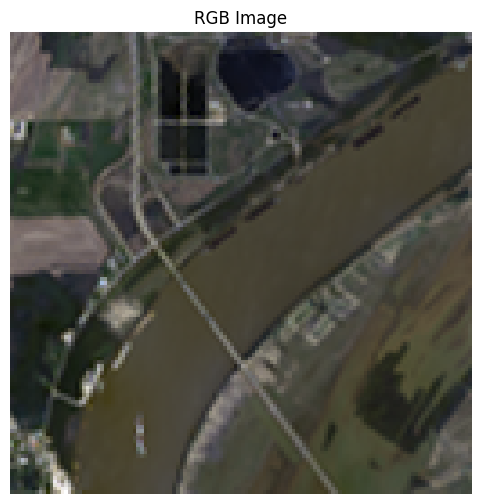

In [131]:
# =====================================
# Display a Random Image as RGB
# =====================================
rgb = np.stack([
    image[3],   # Red
    image[2],   # Green
    image[1]    # Blue
], axis=-1)

# Normalize for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")
plt.show()

Image Shape : (12, 128, 128)


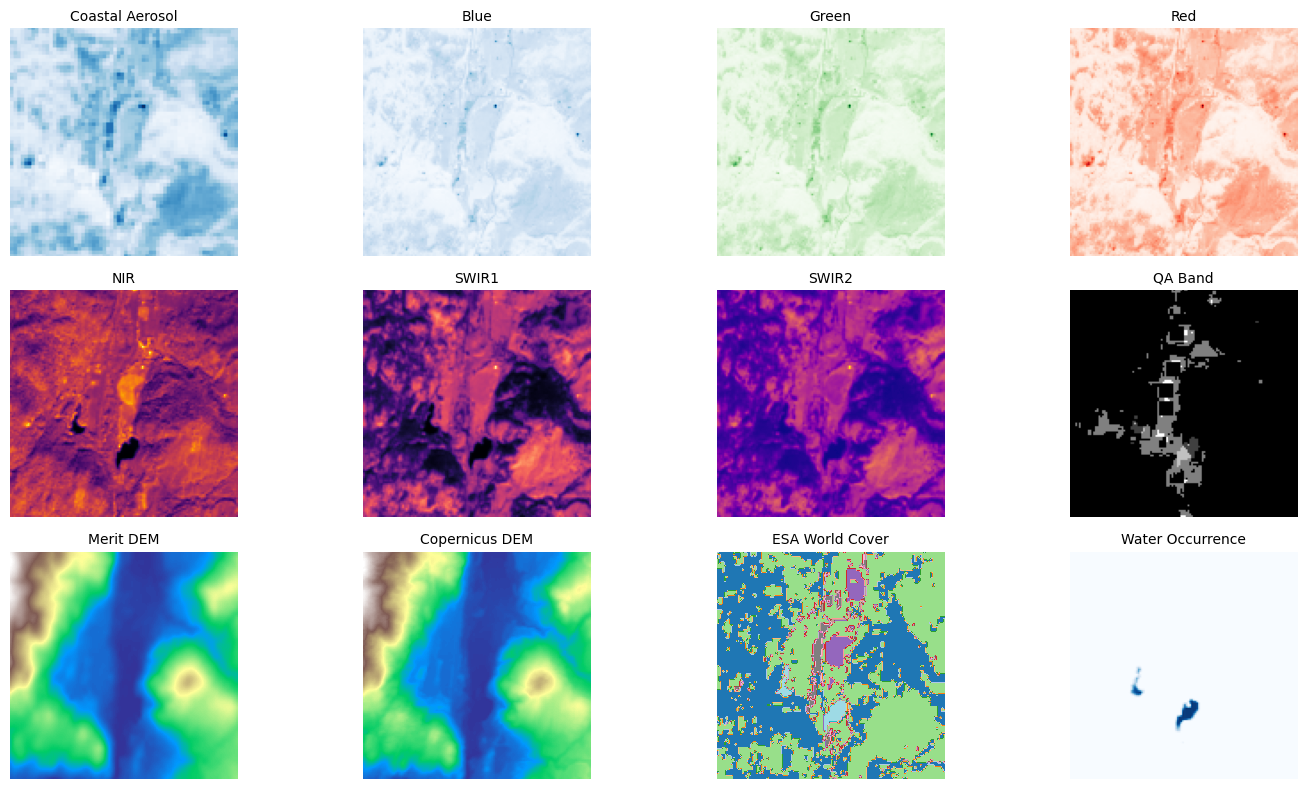

In [132]:
# =====================================
# Display a Random Image and its Bands
# =====================================

import rasterio

image_path = os.path.join(IMAGE_DIR, random.choice(image_files))

with rasterio.open(image_path) as src:
    image = src.read()

print("Image Shape :", image.shape)

band_names = [
    "Coastal Aerosol",
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "QA Band",
    "Merit DEM",
    "Copernicus DEM",
    "ESA World Cover",
    "Water Occurrence"
]
band_cmaps = [
    "Blues",      # Coastal Aerosol
    "Blues",      # Blue
    "Greens",     # Green
    "Reds",       # Red
    "inferno",    # NIR
    "magma",      # SWIR1
    "plasma",     # SWIR2
    "gray",       # QA Band
    "terrain",    # Merit DEM
    "terrain",    # Copernicus DEM
    "tab20",      # ESA World Cover
    "Blues"       # Water Occurrence Probability
]

plt.figure(figsize=(15,8))

for i in range(image.shape[0]):

    plt.subplot(3,4,i+1)

    plt.imshow(image[i], cmap=band_cmaps[i])

    plt.title(band_names[i], fontsize=10)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [133]:
# =====================================
# Train Validation Split
# =====================================

all_files = sorted(os.listdir(IMAGE_DIR))

train_files, val_files = train_test_split(
    all_files,
    test_size=0.2,
    random_state=42
)

print("Train Images :", len(train_files))
print("Validation Images :", len(val_files))

Train Images : 244
Validation Images : 62


In [134]:
# =====================================
# Custom Dataset Class
# =====================================

class WaterDataset(Dataset):

    def __init__(self, file_list, image_dir, label_dir):

        self.file_list = file_list
        self.image_dir = image_dir
        self.label_dir = label_dir

    def __len__(self):

        return len(self.file_list)

    def __getitem__(self, idx):

        # Get image file name
        image_name = self.file_list[idx]

        # Create matching mask name
        mask_name = image_name.replace(".tif", ".png")

        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.label_dir, mask_name)

        # Read multispectral image
        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)
        
        # Normalize each band independently
        for i in range(image.shape[0]):
            band = image[i]
            image[i] = (band - band.min()) / (band.max() - band.min() + 1e-8)

        # Read mask
        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        mask = mask.astype(np.float32)

        # Convert to tensors
        image = torch.tensor(image, dtype=torch.float32)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [135]:
# =====================================
# Create Dataset Objects
# =====================================

train_dataset = WaterDataset(
    train_files,
    IMAGE_DIR,
    LABEL_DIR
)

val_dataset = WaterDataset(
    val_files,
    IMAGE_DIR,
    LABEL_DIR
)

print("Train Samples :", len(train_dataset))
print("Validation Samples :", len(val_dataset))

Train Samples : 244
Validation Samples : 62


In [136]:
# =====================================
# Test Dataset
# =====================================

image, mask = train_dataset[0]

print("Image Shape :", image.shape)
print("Mask Shape :", mask.shape)

print("Image Dtype :", image.dtype)
print("Mask Dtype :", mask.dtype)

Image Shape : torch.Size([12, 128, 128])
Mask Shape : torch.Size([1, 128, 128])
Image Dtype : torch.float32
Mask Dtype : torch.float32


In [137]:
# =====================================
# Create DataLoaders
# =====================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train Batches : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")

Train Batches : 16
Validation Batches : 4


In [138]:
# =====================================
# Test DataLoader
# =====================================

images, masks = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)

Images Shape : torch.Size([16, 12, 128, 128])
Masks Shape  : torch.Size([16, 1, 128, 128])


In [139]:
# =====================================
# Build U-Net Model
# =====================================

import torch
import torch.nn as nn

class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # ==========================
        # Encoder
        # ==========================

        self.enc1 = nn.Sequential(
            nn.Conv2d(12, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.pool4 = nn.MaxPool2d(2)

        # ==========================
        # Bottleneck
        # ==========================

        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),

            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )

        # ==========================
        # Decoder
        # ==========================

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)

        self.dec4 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)

        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)

        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # ==========================
        # Output Layer
        # ==========================

        self.output = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        # ---------- Encoder ----------
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # ---------- Bottleneck ----------
        b = self.bottleneck(p4)

        # ---------- Decoder ----------
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # ---------- Output ----------
        return self.output(d1)

In [140]:
# =====================================
# Create Model
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

print(model)

UNet(
  (enc1): Sequential(
    (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, str

In [141]:
# =====================================
# Define Loss Function
# =====================================

criterion = nn.BCEWithLogitsLoss()

In [142]:
# =====================================
# Define Optimizer
# =====================================

LEARNING_RATE = 1e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [143]:
# =====================================
# Dice Score
# =====================================

def dice_score(preds, targets):

    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum()

    dice = (2 * intersection + 1e-8) / (
        preds.sum() + targets.sum() + 1e-8
    )

    return dice.item()

In [144]:
# =====================================
# IoU Score
# =====================================

def iou_score(preds, targets):

    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum()

    union = preds.sum() + targets.sum() - intersection

    iou = (intersection + 1e-8) / (union + 1e-8)

    return iou.item()

In [145]:
# =====================================
# Training Function
# =====================================

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, masks)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [146]:
# =====================================
# Validation Function
# =====================================

def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            total_loss += loss.item()
            total_dice += dice_score(outputs, masks)
            total_iou += iou_score(outputs, masks)

    return (
        total_loss / len(loader),
        total_dice / len(loader),
        total_iou / len(loader)
    )

In [147]:
# =====================================
# Train Model
# =====================================

EPOCHS = 25

train_losses = []
val_losses = []
dice_scores = []
iou_scores = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, dice, iou = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    dice_scores.append(dice)
    iou_scores.append(iou)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {dice:.4f} | "
        f"IoU: {iou:.4f}"
    )

Epoch [1/25] | Train Loss: 0.5422 | Val Loss: 0.6565 | Dice: 0.6206 | IoU: 0.4582
Epoch [2/25] | Train Loss: 0.4308 | Val Loss: 0.4229 | Dice: 0.7318 | IoU: 0.5801
Epoch [3/25] | Train Loss: 0.3911 | Val Loss: 0.3567 | Dice: 0.7704 | IoU: 0.6296
Epoch [4/25] | Train Loss: 0.3705 | Val Loss: 0.3250 | Dice: 0.7909 | IoU: 0.6561
Epoch [5/25] | Train Loss: 0.3422 | Val Loss: 0.3105 | Dice: 0.7758 | IoU: 0.6381
Epoch [6/25] | Train Loss: 0.3549 | Val Loss: 0.2971 | Dice: 0.7989 | IoU: 0.6671
Epoch [7/25] | Train Loss: 0.3341 | Val Loss: 0.3160 | Dice: 0.7958 | IoU: 0.6631
Epoch [8/25] | Train Loss: 0.3182 | Val Loss: 0.2895 | Dice: 0.8235 | IoU: 0.7021
Epoch [9/25] | Train Loss: 0.3118 | Val Loss: 0.3007 | Dice: 0.8032 | IoU: 0.6735
Epoch [10/25] | Train Loss: 0.3062 | Val Loss: 0.3076 | Dice: 0.8059 | IoU: 0.6761
Epoch [11/25] | Train Loss: 0.2893 | Val Loss: 0.2621 | Dice: 0.8141 | IoU: 0.6889
Epoch [12/25] | Train Loss: 0.2981 | Val Loss: 0.2883 | Dice: 0.8156 | IoU: 0.6905
Epoch [13/25]

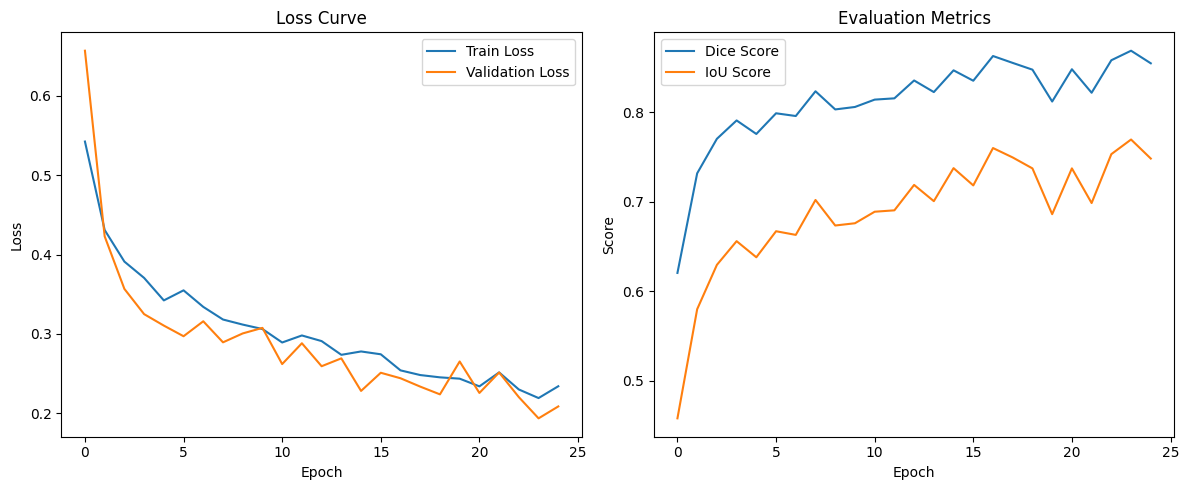

In [148]:
# =====================================
# Plot Training History
# =====================================

plt.figure(figsize=(12,5))

# Training & Validation Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Metrics
plt.subplot(1,2,2)
plt.plot(dice_scores, label="Dice Score")
plt.plot(iou_scores, label="IoU Score")
plt.title("Evaluation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()

In [149]:
# =====================================
# Calculate Evaluation Metrics
# =====================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

model.eval()

all_preds = []
all_masks = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        outputs = model(images)

        outputs = torch.sigmoid(outputs)
        outputs = (outputs > 0.5).float()

        all_preds.extend(outputs.cpu().numpy().flatten())
        all_masks.extend(masks.numpy().flatten())

precision = precision_score(all_masks, all_preds)
recall = recall_score(all_masks, all_preds)
f1 = f1_score(all_masks, all_preds)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.8554
Recall    : 0.8641
F1 Score  : 0.8597


In [150]:
# =====================================
# Predict Mask
# =====================================

model.eval()

def predict(model, image):

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image)

        output = torch.sigmoid(output)

        output = (output > 0.5).float()

    return output.squeeze().cpu().numpy()

In [151]:
# =====================================
# Display Prediction Results
# =====================================

sample_index = random.randint(0, len(val_dataset)-1)

image, mask = val_dataset[sample_index]

prediction = predict(model, image)

c:\Python\Lib\site-packages\rasterio\__init__.py:317: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


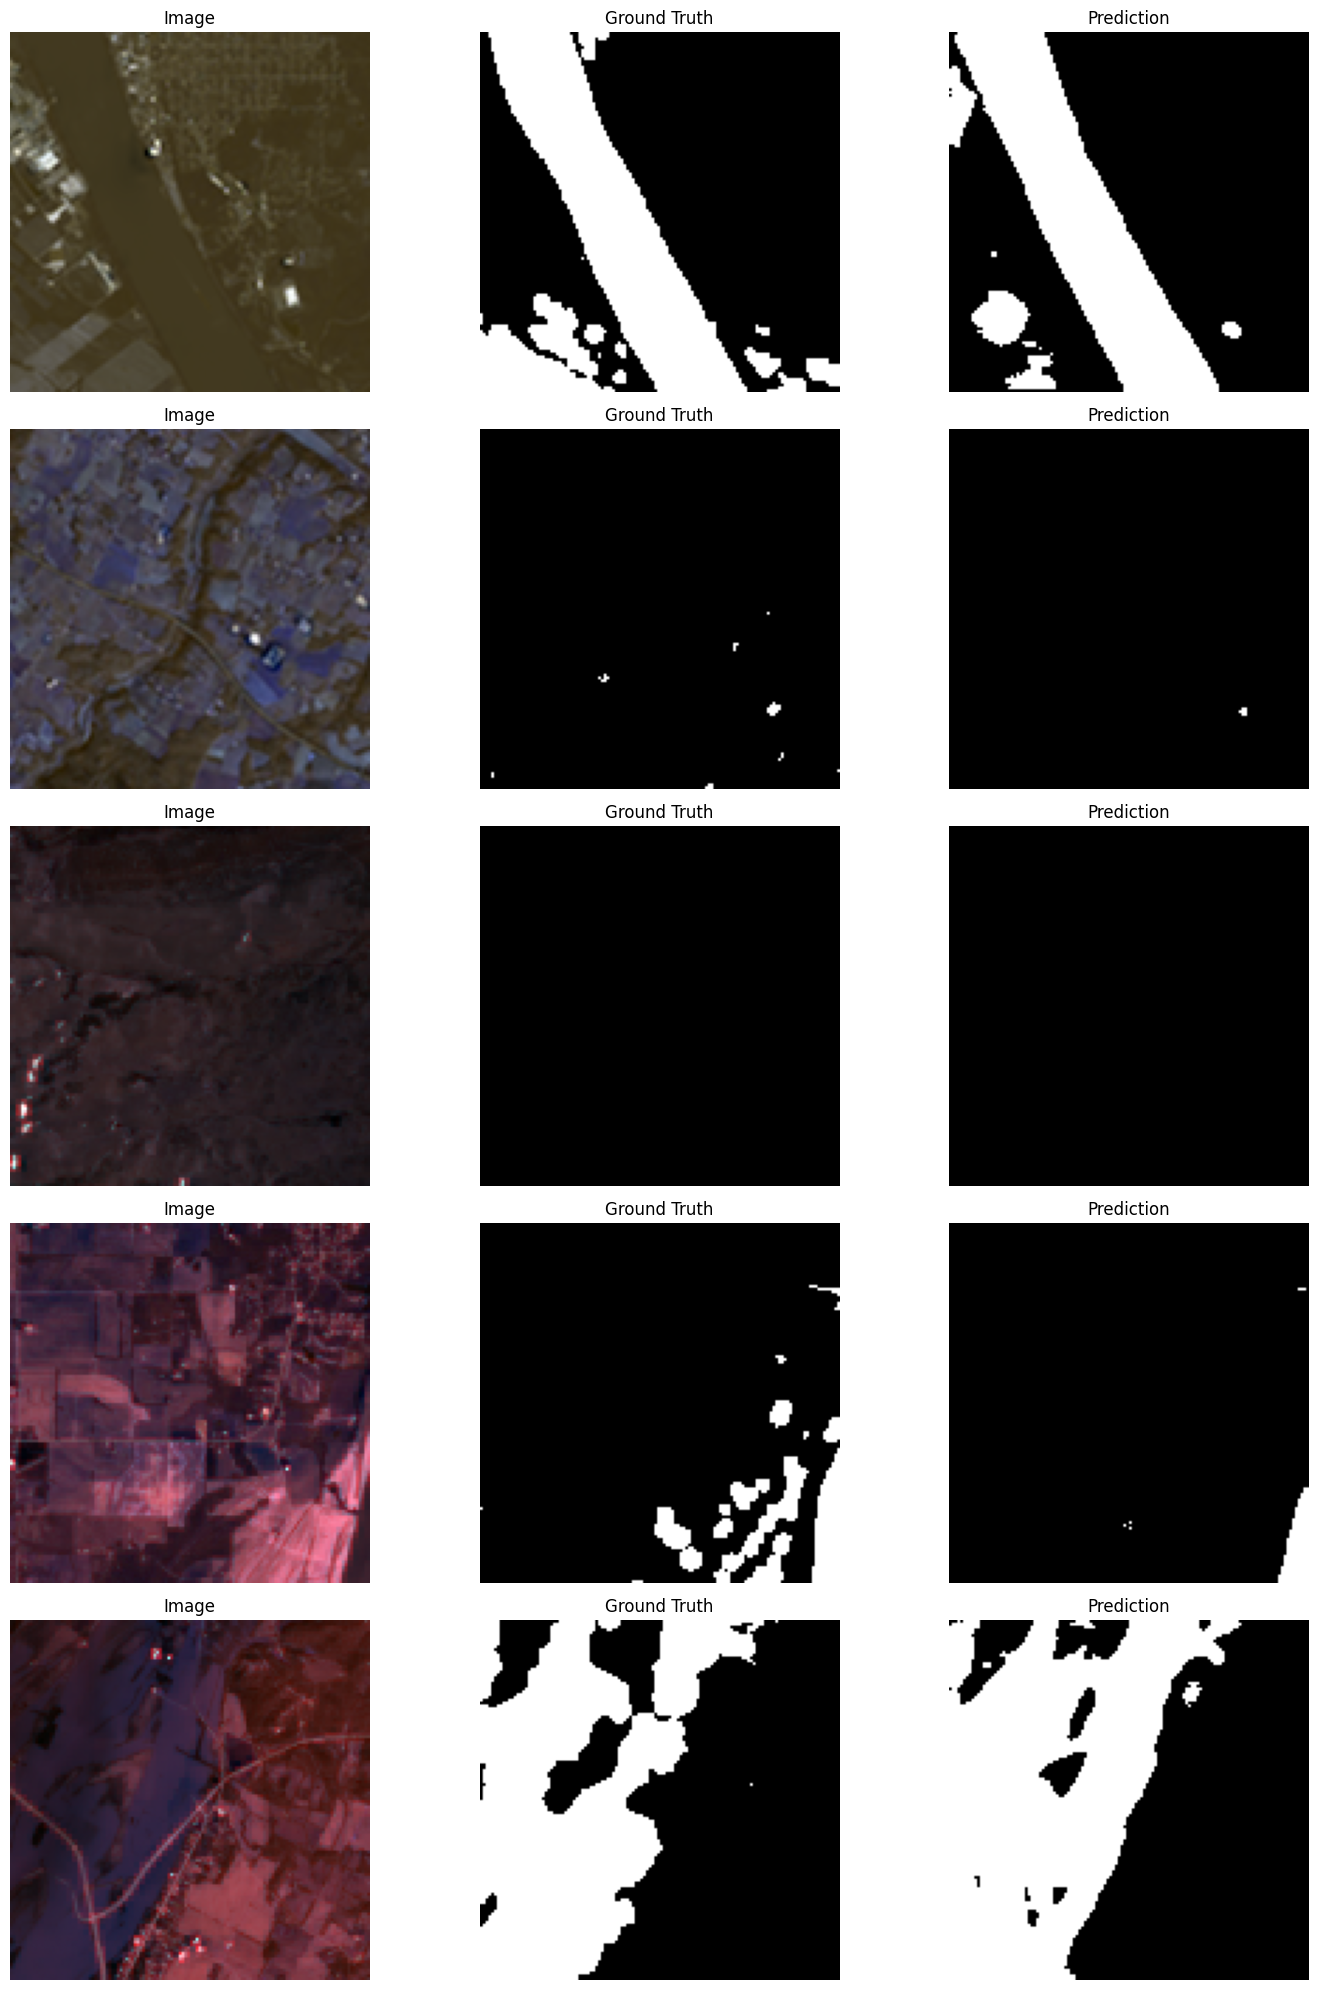

In [154]:
# =====================================
# Display Multiple Predictions
# =====================================

plt.figure(figsize=(15,20))

for i in range(5):

    image, mask = val_dataset[random.randint(0, len(val_dataset)-1)]

    prediction = predict(model, image)

    rgb = image[:3].permute(1,2,0).numpy()

    # Original Image
    plt.subplot(5,3,3*i+1)
    plt.imshow(rgb)
    plt.title("Image")
    plt.axis("off")

    # Ground Truth
    plt.subplot(5,3,3*i+2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(5,3,3*i+3)
    plt.imshow(prediction, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()